In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [3]:
X = np.array([1,2,3,4,5]).reshape(-1,1)

In [4]:
X

array([[1],
       [2],
       [3],
       [4],
       [5]])

In [24]:
Y = np.array([40,50,50,60,70])

In [25]:
model = LinearRegression()
model.fit(X,Y)

LinearRegression()

In [26]:
print("Intercept: ",model.intercept_)
print("Slope: ",model.coef_[0])

Intercept:  33.0
Slope:  7.0


In [27]:
new_data = np.array([[6]])
predicted_mark = model.predict(new_data)

In [28]:
print("Predicted mark: ",predicted_mark[0])

Predicted mark:  75.0


In [29]:
y_pred = model.predict(X)
y_pred

array([40., 47., 54., 61., 68.])

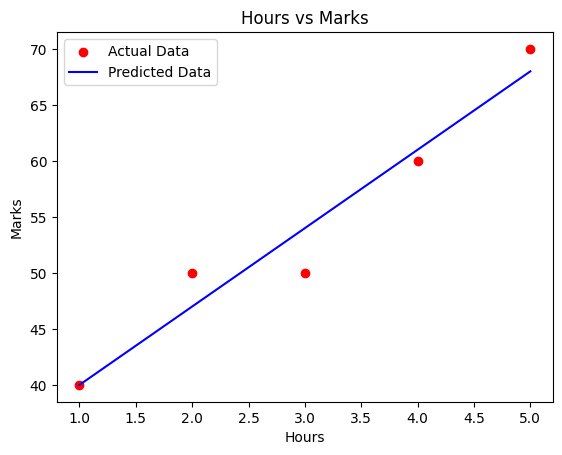

In [30]:
plt.scatter(X,Y,color='red',label='Actual Data')
plt.plot(X,y_pred,color='blue',label='Predicted Data')
plt.xlabel('Hours')
plt.ylabel('Marks')
plt.title('Hours vs Marks')
plt.legend()
plt.show()

In [31]:
import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

In [32]:
mae = mean_absolute_error(Y,y_pred)
mse = mean_squared_error(Y,y_pred)
r2 = r2_score(Y,y_pred)

In [33]:
mae


2.0

In [34]:
mse

6.0

In [35]:
r2

0.9423076923076923

In [36]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [37]:
data = {
    "Study_hours": [1,2,3,4,5,6,7,8,9,10],
    "Marks": [32,38,43,50,54,61,68,73,81,88]
}

In [40]:
df = pd.DataFrame(data)
df

,Study_hours,Marks
0,1,32
1,2,38
2,3,43
3,4,50
4,5,54
5,6,61
6,7,68
7,8,73
8,9,81
9,10,88


In [46]:
X = df[["Study_hours"]]
Y = df["Marks"]
x_train, x_test, y_train, y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [48]:
model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

In [49]:
print("Intercept: ", model.intercept_)
print("Slope: ", model.coef_[0])
print("Actual values: ",y_test.values)
print("Predicted values: ",y_pred)

Intercept:  24.724137931034484
Slope:  6.163793103448276
Actual values:  [81 38]
Predicted values:  [80.19827586 37.05172414]


In [51]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE: ",np.sqrt(mean_squared_error(y_test, y_pred)))

MAE: 0.875
MSE: 0.7709943519619504
R2 Score: 0.9983320836085193
RMSE:  0.8780628405541089


Multiple Linear Regression

In [52]:
import pandas as pd
from sklearn.linear_model import LinearRegression


In [74]:
data = {
    "Study_hours": [2,3,4,5,6,7,8,9],
    "Attendance":[60,65,70,75,80,85,90,95],
    "Assignment_score": [50,55,58,65,70,74,80,88],
    "Final_marks" : [42,48,54,61,67,73,81,89]
}

In [75]:
df = pd.DataFrame(data)
X = df[["Study_hours","Attendance","Assignment_score"]]
Y = df["Final_marks"]

In [76]:
model = LinearRegression()
model.fit(X,Y)

LinearRegression()

In [77]:
print("Intercept: ", model.intercept_)

Intercept:  -28.31652806652808


In [78]:
coeeficient_table = pd.DataFrame({
    "Features": X.columns,
    "Coefficients": model.coef_
})
coeeficient_table

,Features,Coefficients
0,Study_hours,0.131410
1,Attendance,0.657051
2,Assignment_score,0.608108


In [79]:
new_student = pd.DataFrame({
    "Study_hours": [6],
    "Attendance": [82],
    "Assignment_score": [72]
})

In [80]:
prediction = model.predict(new_student)
print("Predicted Marks: ",prediction[0])

Predicted Marks:  70.13392238392238


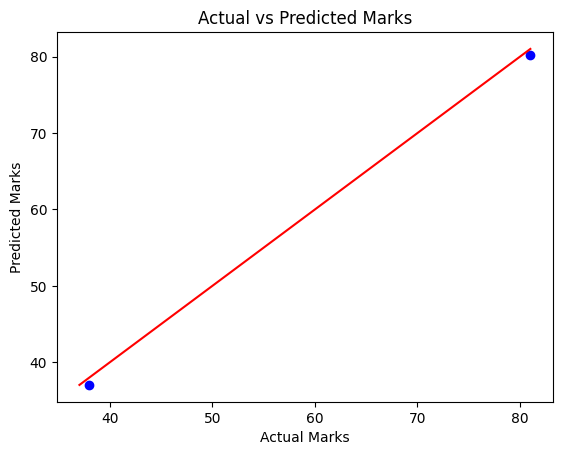

In [88]:
import matplotlib.pyplot as plt
import builtins # Import the builtins module

plt.scatter(y_test,y_pred,color='blue')
min_val = builtins.min(y_test.min(),y_pred.min())
max_val = builtins.max(y_test.max(),y_pred.max())
plt.plot([min_val,max_val],[min_val,max_val],color='red')
plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted Marks")
plt.show()

Residual Plot(How to plot errors)

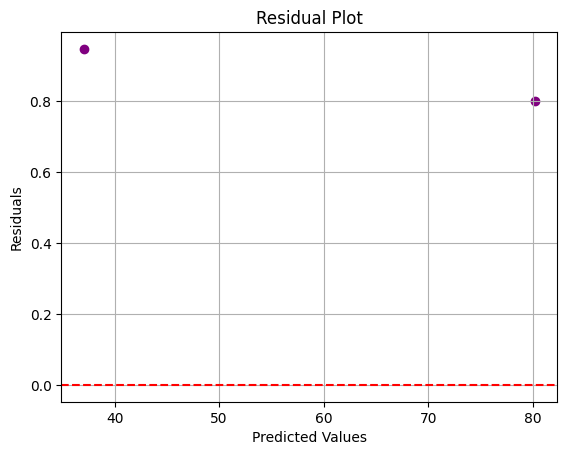

In [83]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals,color='purple')
plt.axhline(y=0,color="red",linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid()
plt.show()

In [89]:
#Suppose house price depends on house size and location

In [90]:
import pandas as pd
data ={
    "Size": [800,1000,1200,1500,1800],
    "Location": ["Rural","Urban","Rural","Urban","Urban"],
    "price": [30,50,42,72,85]
}

df = pd.DataFrame(data)
df_encoded = pd.get_dummies(df,columns=["Location"],drop_first=True)
df_encoded

,Size,price,Location_Urban
0,800,30,False
1,1000,50,True
2,1200,42,False
3,1500,72,True
4,1800,85,True
